In [1]:
import torch
import torch.nn as nn

## Helpers

In [2]:
import html
import matplotlib
from matplotlib.colors import Normalize, to_hex
from IPython.display import HTML

def colorize(tokens:list[str], weights:list[float], target:str=None):
    """returns a html heatmap representation of the tokens colored by weights.
        tokens and weights should match in lenghth
        target is optionally the token the weights were calculated for
    """
    template = '<span style="color: black; background-color: {}">{}</span>'
    colors = map(to_hex, matplotlib.colormaps['bwr'](Normalize(vmin=-1, vmax=1)(weights)))
    colored_output = ''
    for token, color in zip(tokens, colors):
        colored_output += template.format(color, '&nbsp'+html.escape(token)+'&nbsp')
    if target:
        colored_output += template.format('lime', '&nbsp'+html.escape(target)+'&nbsp')
    return HTML(colored_output)

In [3]:
from crp.image import imgify
# attribute prediction
def attribute_max(image, model):
    inputs = processor(images=image, return_tensors="pt").to('cuda')
    input_pixels = inputs['pixel_values']
    outputs = model(pixel_values=input_pixels.requires_grad_())
    logits = outputs['logits']
    
    # model predicts one of the 1000 ImageNet classes
    max_logit, predicted_class_idx = logits.max(-1)
    print(f"Predicted class {predicted_class_idx.item()} (Logit: {max_logit.item():.02f}):", model.config.id2label[predicted_class_idx.item()])

    max_logit.backward(max_logit)

    # normalize the heatmap
    heatmap = input_pixels.grad[0].sum(0)
    heatmap = heatmap / abs(heatmap).max()
    #heatmaps.append(heatmap.cpu().numpy())

    #imgify(input_pixels[0].detach().cpu(), vmin=-1, vmax=1)
    return imgify(heatmap.cpu(), vmin=-1, vmax=1)

In [4]:
from IPython.display import display

def attribute_topk(k, image, model, largest=True, norm_relative_to_max=True):
    inputs = processor(images=image, return_tensors="pt").to('cuda')
    input_pixels = inputs['pixel_values']
    outputs = model(pixel_values=input_pixels.requires_grad_())
    logits = outputs['logits']
    topk_indices = logits.topk(k, largest=largest).indices[0].tolist()
    
    for idx in topk_indices:
        display(attribute_idx(idx, image, model, norm_relative_to_max=norm_relative_to_max))

In [5]:
def search_balanced_idx(image, model, var=0.009, max_logit=1):
    # find class idx with balanced attribution for image
    # balanced attribution means positive and negative support cancel each other
    # consequently logit is near zero, but we need to filter out cases where support is uniformly zero
    inputs = processor(images=image, return_tensors="pt").to('cuda')
    input_pixels = inputs['pixel_values']
    outputs = model(pixel_values=input_pixels.requires_grad_())
    logits = outputs['logits']
    
    logit_indices = logits.detach().abs().argsort().transpose(1, 0)
    
    # test for uniform attribution
    balanced_indices = []
    batchsize = 32
    input_batch = input_pixels.repeat(batchsize, 1, 1, 1).detach() # batch compute attribution
    logits = model(pixel_values=input_batch.requires_grad_())['logits']
    init_grad = torch.zeros_like(logits)
    
    for i in range(logit_indices.shape[0]//batchsize):
        print(i, end='\r')
        logits_chunk = logit_indices[i*batchsize:min((i+1)*batchsize, len(logit_indices))]
        input_batch.grad = None
        init_grad = init_grad.zero_().scatter_(1, logits_chunk, logits.gather(1, logits_chunk))

        logits.backward(init_grad, retain_graph=True)
        
        relevances = input_batch.grad.sum(1).flatten(1)
        relevances = relevances / (relevances.abs().max(1)[0][:,None]+1e-24)
        balanced = (relevances.var(dim=1) > var)
        
        if any(balanced):
            balanced_indices.extend(logits_chunk[balanced.nonzero(as_tuple=True)].flatten().tolist())
            
        if torch.any(init_grad.abs() > max_logit):
            break
    
    # garbage collect the large input batch
    del input_batch
    del logits
    return balanced_indices

In [6]:
from crp.image import imgify
# attribute alternative
def attribute_idx(idx, image, model, norm_relative_to_max=False):
    inputs = processor(images=image, return_tensors="pt").to('cuda')
    input_pixels = inputs['pixel_values']
        
    outputs = model(pixel_values=input_pixels.requires_grad_())        
    logits = outputs['logits']
    # model predicts one of the 1000 ImageNet classes
    logit = logits[0, idx]
    print(f"Alternative class {idx} (Logit: {logit.item():.02f}):", model.config.id2label[idx])

    logit.backward(logit)

    # normalize the heatmap
    heatmap = input_pixels.grad[0].sum(0)
    
    if norm_relative_to_max:
        # compute attribution for max logit
        input_pixels.grad = None
        outputs = model(pixel_values=input_pixels.requires_grad_())        
        logits = outputs['logits']
        max_logit, predicted_class_idx = logits.max(-1)
        max_logit.backward(max_logit)
        max_heatmap = input_pixels.grad[0].sum(0)
        heatmap = heatmap / abs(max_heatmap).max()
    else:
        heatmap = heatmap / abs(heatmap).max()

    return imgify(heatmap.cpu(), vmin=-1, vmax=1)

## Modified Model

In [7]:
from transformers import ViTImageProcessor
from lxt.explicit.models.vit import ViTForImageClassification, attnlrp

checkpoint = "google/vit-large-patch32-384"
processor = ViTImageProcessor.from_pretrained(checkpoint, device_map="cuda")
vit_model = ViTForImageClassification.from_pretrained(checkpoint, attn_implementation="eager", device_map="cuda");
config = vit_model.config

/scratch/koegel/.conda-envs/playground/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
attnlrp.register(vit_model);

In [9]:
from PIL import Image
import requests

url = "https://github.com/rachtibat/LRP-eXplains-Transformers/blob/main/docs/source/_static/cat_dog.jpg?raw=true"
image = Image.open(requests.get(url, stream=True).raw)

Predicted class 156 (Logit: 11.99): Blenheim spaniel


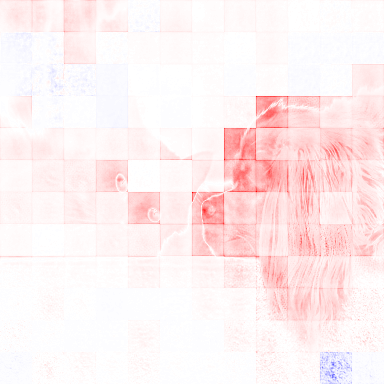

In [10]:
attribute_max(image, vit_model)

Alternative class 156 (Logit: 11.99): Blenheim spaniel


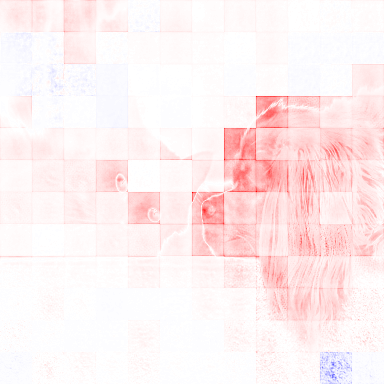

Alternative class 220 (Logit: 9.18): Sussex spaniel


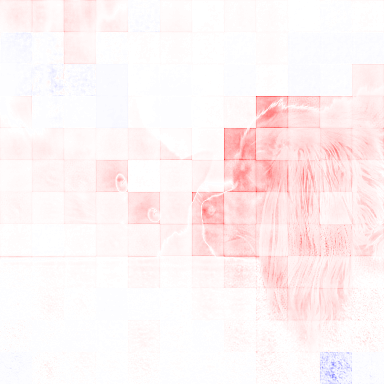

Alternative class 219 (Logit: 8.94): cocker spaniel, English cocker spaniel, cocker


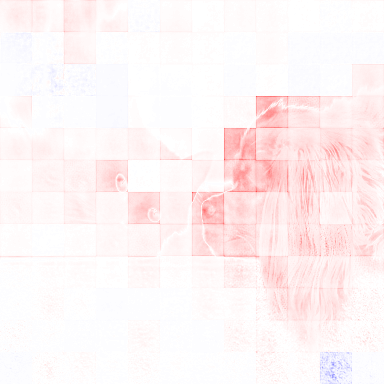

In [11]:
# in Vit the top k class attributions are very similar, but lower relative to top prediction
attribute_topk(3, image, vit_model, norm_relative_to_max=True)

Alternative class 771 (Logit: -2.44): safe


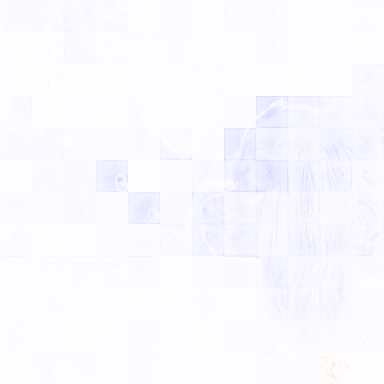

Alternative class 644 (Logit: -2.23): matchstick


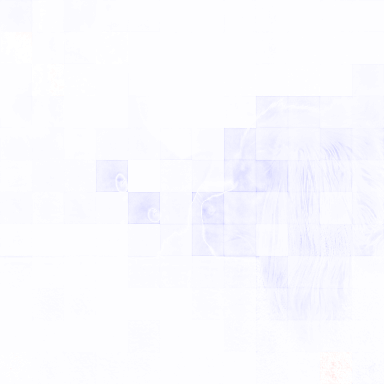

Alternative class 507 (Logit: -2.22): combination lock


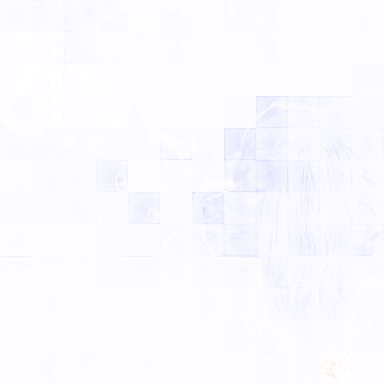

In [12]:
# The bottom k classes are objects, attributions clearly indicate the animal parts as negative support
attribute_topk(3, image, vit_model, largest=False, norm_relative_to_max=True)

In [13]:
# let's look at alternative classes such as cats
list(filter(lambda i: 'cat' in i[1], config.id2label.items()))

[(30, 'bullfrog, Rana catesbeiana'),
 (89, 'sulphur-crested cockatoo, Kakatoe galerita, Cacatua galerita'),
 (143, 'oystercatcher, oyster catcher'),
 (281, 'tabby, tabby cat'),
 (282, 'tiger cat'),
 (283, 'Persian cat'),
 (284, 'Siamese cat, Siamese'),
 (285, 'Egyptian cat'),
 (286,
  'cougar, puma, catamount, mountain lion, painter, panther, Felis concolor'),
 (287, 'lynx, catamount'),
 (358, 'polecat, fitch, foulmart, foumart, Mustela putorius'),
 (361, 'skunk, polecat, wood pussy'),
 (383, 'Madagascar cat, ring-tailed lemur, Lemur catta'),
 (387, 'lesser panda, red panda, panda, bear cat, cat bear, Ailurus fulgens'),
 (484, 'catamaran'),
 (688, 'oscilloscope, scope, cathode-ray oscilloscope, CRO')]

Alternative class 282 (Logit: 0.99): tiger cat


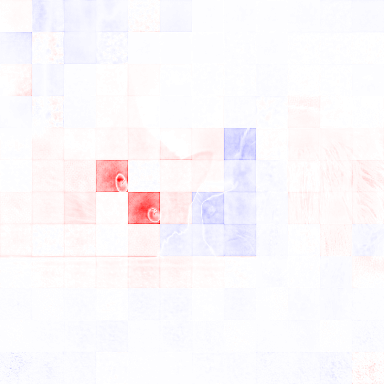

Alternative class 282 (Logit: 0.99): tiger cat


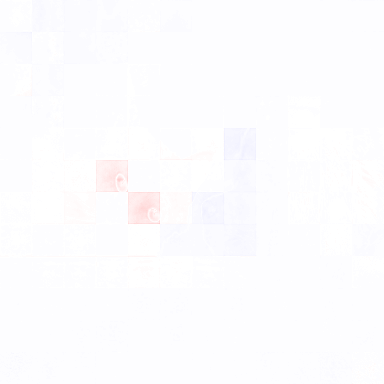

In [15]:
# specific classes can be more discriminative
display(attribute_idx(282, image, vit_model))
attribute_idx(282, image, vit_model, norm_relative_to_max=True)

Alternative class 287 (Logit: -0.22): lynx, catamount


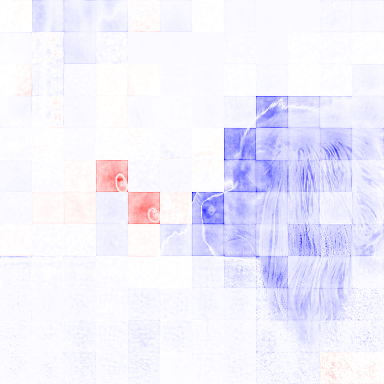

Alternative class 287 (Logit: -0.22): lynx, catamount


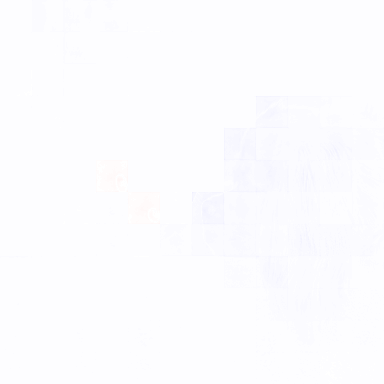

In [16]:
# this is an example of low logit where positive and negative support balance out
# a lynx has cat eyes but clearly different head, snout and fur than a dog
display(attribute_idx(287, image, vit_model))
# but very low overall relative to top prediction
attribute_idx(287, image, vit_model, norm_relative_to_max=True)

In [17]:
#balanced_indices = search_balanced_idx(image, vit_model)
balanced_indices = [722, 498, 604, 293, 463, 287, 316, 133, 737, 641, 773, 487, 311, 381, 881, 474, 951, 750, 429, 860, 677, 327, 330, 974, 674, 849, 562, 923, 519, 752]

Alternative class 722 (Logit: 0.03): ping-pong ball


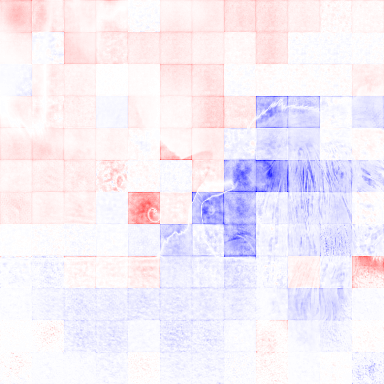

In [18]:
attribute_idx(balanced_indices[0], image, vit_model)

Alternative class 688 (Logit: -0.89): oscilloscope, scope, cathode-ray oscilloscope, CRO


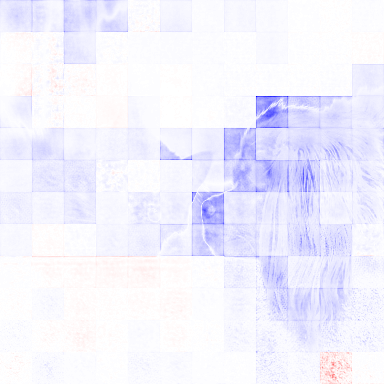

In [41]:
# non-animal classes have clearly no support in the model
attribute_idx(688, image, vit_model)

## CRP

In [11]:
class WrapModel(nn.Module):

    def __init__(self, model):
        super(WrapModel, self).__init__()
        self.model = model
        
    def forward(self, *args, **kwargs):
        output = vit_model(*args, **kwargs)
        return output['logits']

In [12]:
from importlib import reload
import crp.attribution
reload(crp.attribution)

<module 'crp.attribution' from '/projects/koegel/code/crp/crp/attribution.py'>

In [13]:
from crp.attribution import CondAttribution
from crp.helper import get_layer_names

model = WrapModel(vit_model)
attribution = CondAttribution(model, no_param_grad=True)

image = Image.open('lizard.jpg')
sample = processor(images=image, return_tensors="pt").to('cuda')['pixel_values']

# zennit requires gradients
sample.requires_grad = True

In [14]:
# or use a dictionary for mask_map
get_layer_names(model, [torch.nn.Conv2d, torch.nn.Linear])

['model.vit.embeddings.patch_embeddings.projection',
 'model.vit.encoder.layer.0.attention.attention.query',
 'model.vit.encoder.layer.0.attention.attention.key',
 'model.vit.encoder.layer.0.attention.attention.value',
 'model.vit.encoder.layer.0.attention.output.dense',
 'model.vit.encoder.layer.0.intermediate.dense',
 'model.vit.encoder.layer.0.output.dense',
 'model.vit.encoder.layer.1.attention.attention.query',
 'model.vit.encoder.layer.1.attention.attention.key',
 'model.vit.encoder.layer.1.attention.attention.value',
 'model.vit.encoder.layer.1.attention.output.dense',
 'model.vit.encoder.layer.1.intermediate.dense',
 'model.vit.encoder.layer.1.output.dense',
 'model.vit.encoder.layer.2.attention.attention.query',
 'model.vit.encoder.layer.2.attention.attention.key',
 'model.vit.encoder.layer.2.attention.attention.value',
 'model.vit.encoder.layer.2.attention.output.dense',
 'model.vit.encoder.layer.2.intermediate.dense',
 'model.vit.encoder.layer.2.output.dense',
 'model.vit.en

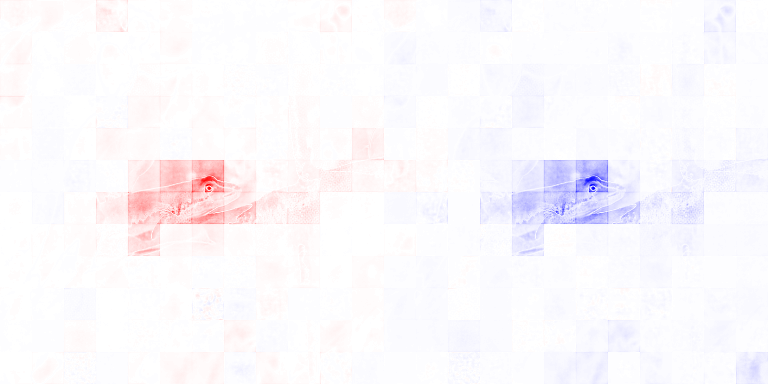

In [15]:
from crp.image import imgify

# compute heatmap wrt. output 46 (green lizard class) and (722 ping-pong ball)
conditions = [{"y": 46}, {"y": 722}]

heatmaps, *_ = attribution(sample, conditions)
imgify(heatmaps[0].sum(-3), symmetric=True, grid=(1, len(heatmaps[0])))

### Concepts

In [72]:
layer_of_interest = 'model.vit.encoder.layer.10.output.dense'
attr = attribution(sample, [{"y": 46}], record_layer=[layer_of_interest])
attr.activations[layer_of_interest].shape, attr.relevances[layer_of_interest].shape

(torch.Size([1, 145, 1024]), torch.Size([1, 145, 1024]))

In [73]:
from crp.concepts import TransformerChannelConcept

cc = TransformerChannelConcept()

# TransformerChannelConcept.attribute aggregates the relevances for individual elements according to the concept definition 
rel_c = cc.attribute(attr.relevances[layer_of_interest], abs_norm=True)
rel_c.shape

torch.Size([1, 1024])

In [74]:
# the six most relevant concepts and their contribution to final classification in percent
rel_values, concept_ids = torch.topk(rel_c[0], 10)
concept_ids, rel_values*100

(tensor([188, 310, 721, 670,  25, 584, 695, 437, 350, 354], device='cuda:0'),
 tensor([3.9148, 1.1995, 0.5601, 0.5384, 0.4743, 0.4709, 0.4666, 0.4477, 0.4386,
         0.4366], device='cuda:0'))

top 10 concepts in layer 10


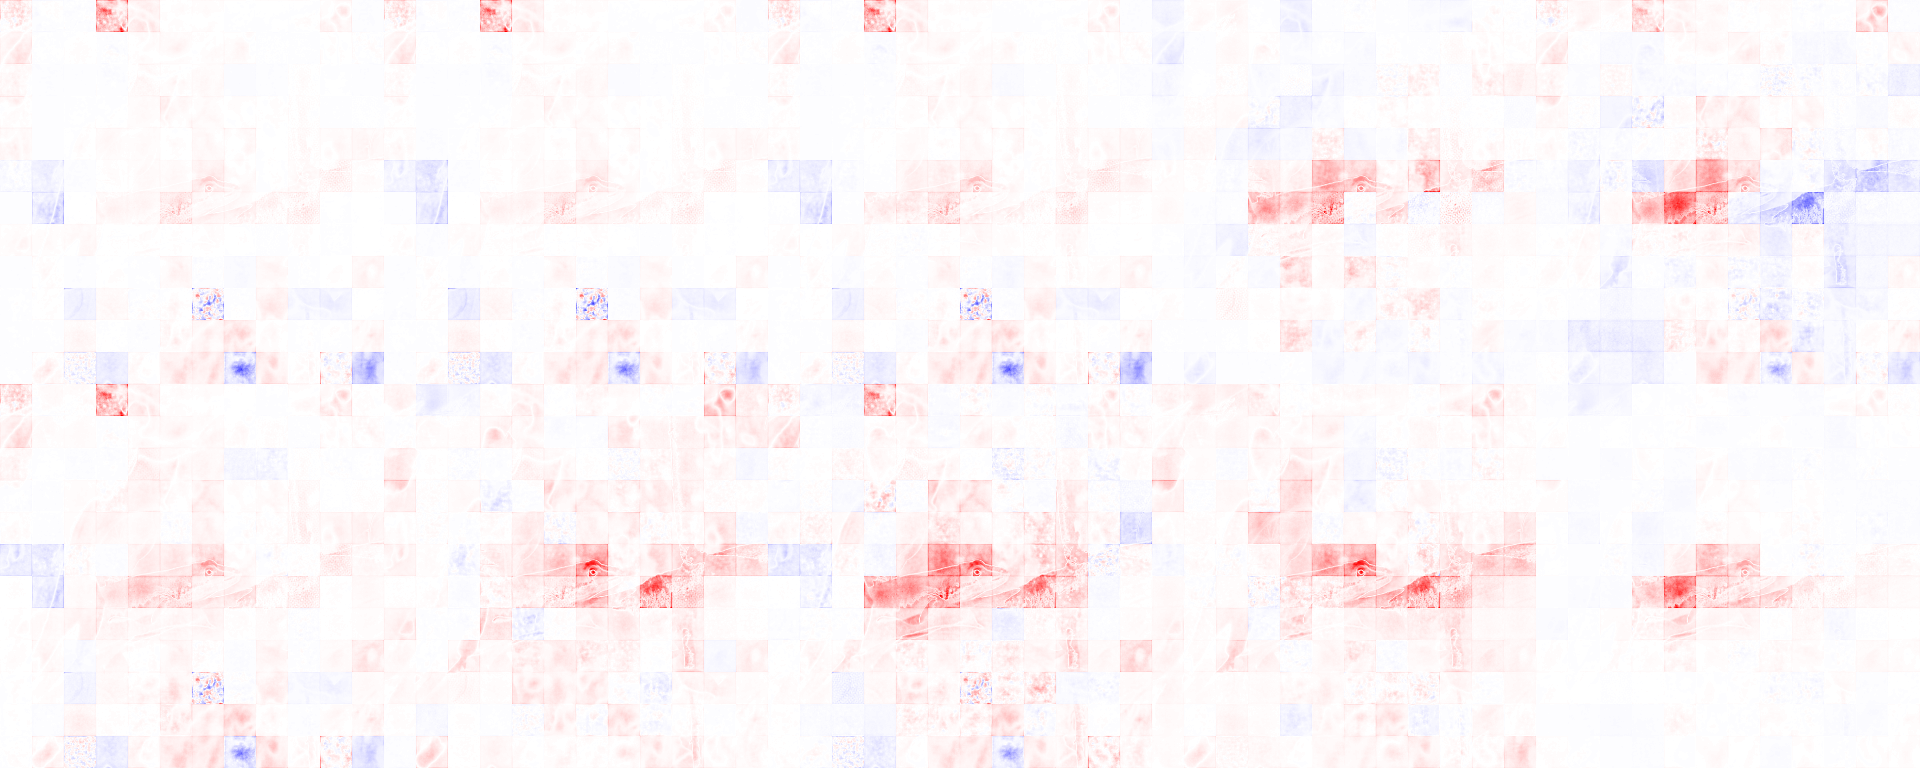

In [76]:
conditions = [{'y': [46], layer_of_interest: [id]} for id in concept_ids]
heatmaps, *_ = attribution(sample, conditions)
print("top 10 concepts in layer 10")
imgify(heatmaps[0].sum(-3), symmetric=True, grid=(2, len(heatmaps[0])//2))

Conditioning on the level of patch embeddings does not seem to make much sense, let's go to neuron level

In [77]:
# find top relevant channel (embedding) in layer and relevance to classification in percent
layer_of_interest = 'model.vit.encoder.layer.10.output.dense'
attr = attribution(sample, [{"y": 46}], record_layer=[layer_of_interest])
rel_c = cc.attribute(attr.relevances[layer_of_interest], abs_norm=True)
top_channel_rel, top_channel_id = rel_c.max(dim=-1)
top_channel_id, top_channel_rel*100

(tensor([188], device='cuda:0'), tensor([3.9148], device='cuda:0'))

In [78]:
# find the six most relevant neurons and their contribution (through top channel) to final classification in percent
rel_values, topk_neuron_ids = torch.topk(attr.relevances[layer_of_interest][0, :, top_channel_id].cpu(), 6, dim=0)
topk_neuron_ids, rel_values*100

(tensor([[ 61],
         [144],
         [ 74],
         [  1],
         [143],
         [ 62]]),
 tensor([[1.5624],
         [1.4491],
         [1.3384],
         [1.2001],
         [1.1602],
         [1.1237]]))

top 6 neurons in top channel of layer 10


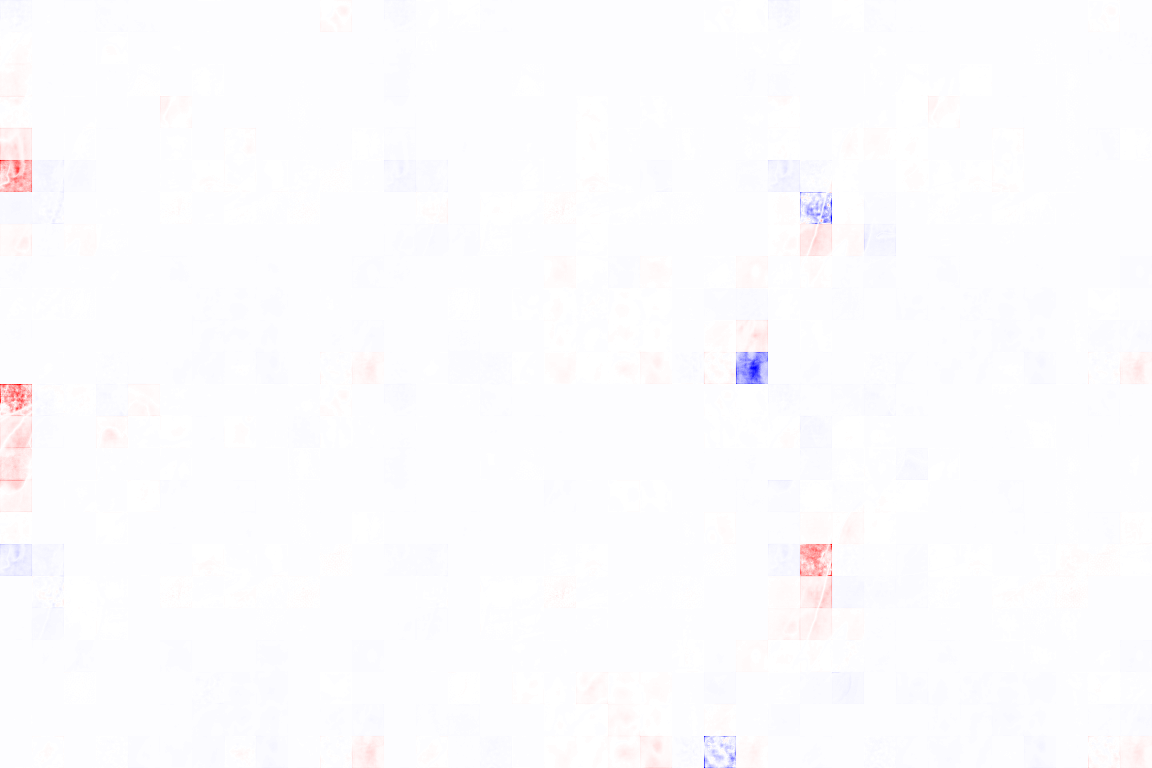

In [79]:
conditions = [{'y': [46], layer_of_interest: {top_channel_id:id}} for id in topk_neuron_ids]
heatmaps, *_ = attribution(sample, conditions, mask_map=TransformerChannelConcept.mask_rf)
print("top 6 neurons in top channel of layer 10")
imgify(heatmaps[0].sum(-3), symmetric=True, grid=(2, len(heatmaps[0])//2))

In [ ]:
layers = [f'model.vit.encoder.layer.{i}.output.dense' for i in range(1, 23)]
attr = attribution(sample, [{"y": 46}], record_layer=layers)

(torch.Size([1, 145, 1024]), torch.Size([1, 145, 1024]))

In [98]:
top_channel_per_layer = {}
relevance_per_layer = []
for layer in layers:
    rel_c = cc.attribute(attr.relevances[layer], abs_norm=True)
    top_channel_per_layer[layer] = torch.argmax(rel_c[0]).item()
    relevance_per_layer.append(rel_c[0].max().item())

 12%|█▏        | 5/43 [44:30<5:38:14, 534.06s/it]


top channel in each layer


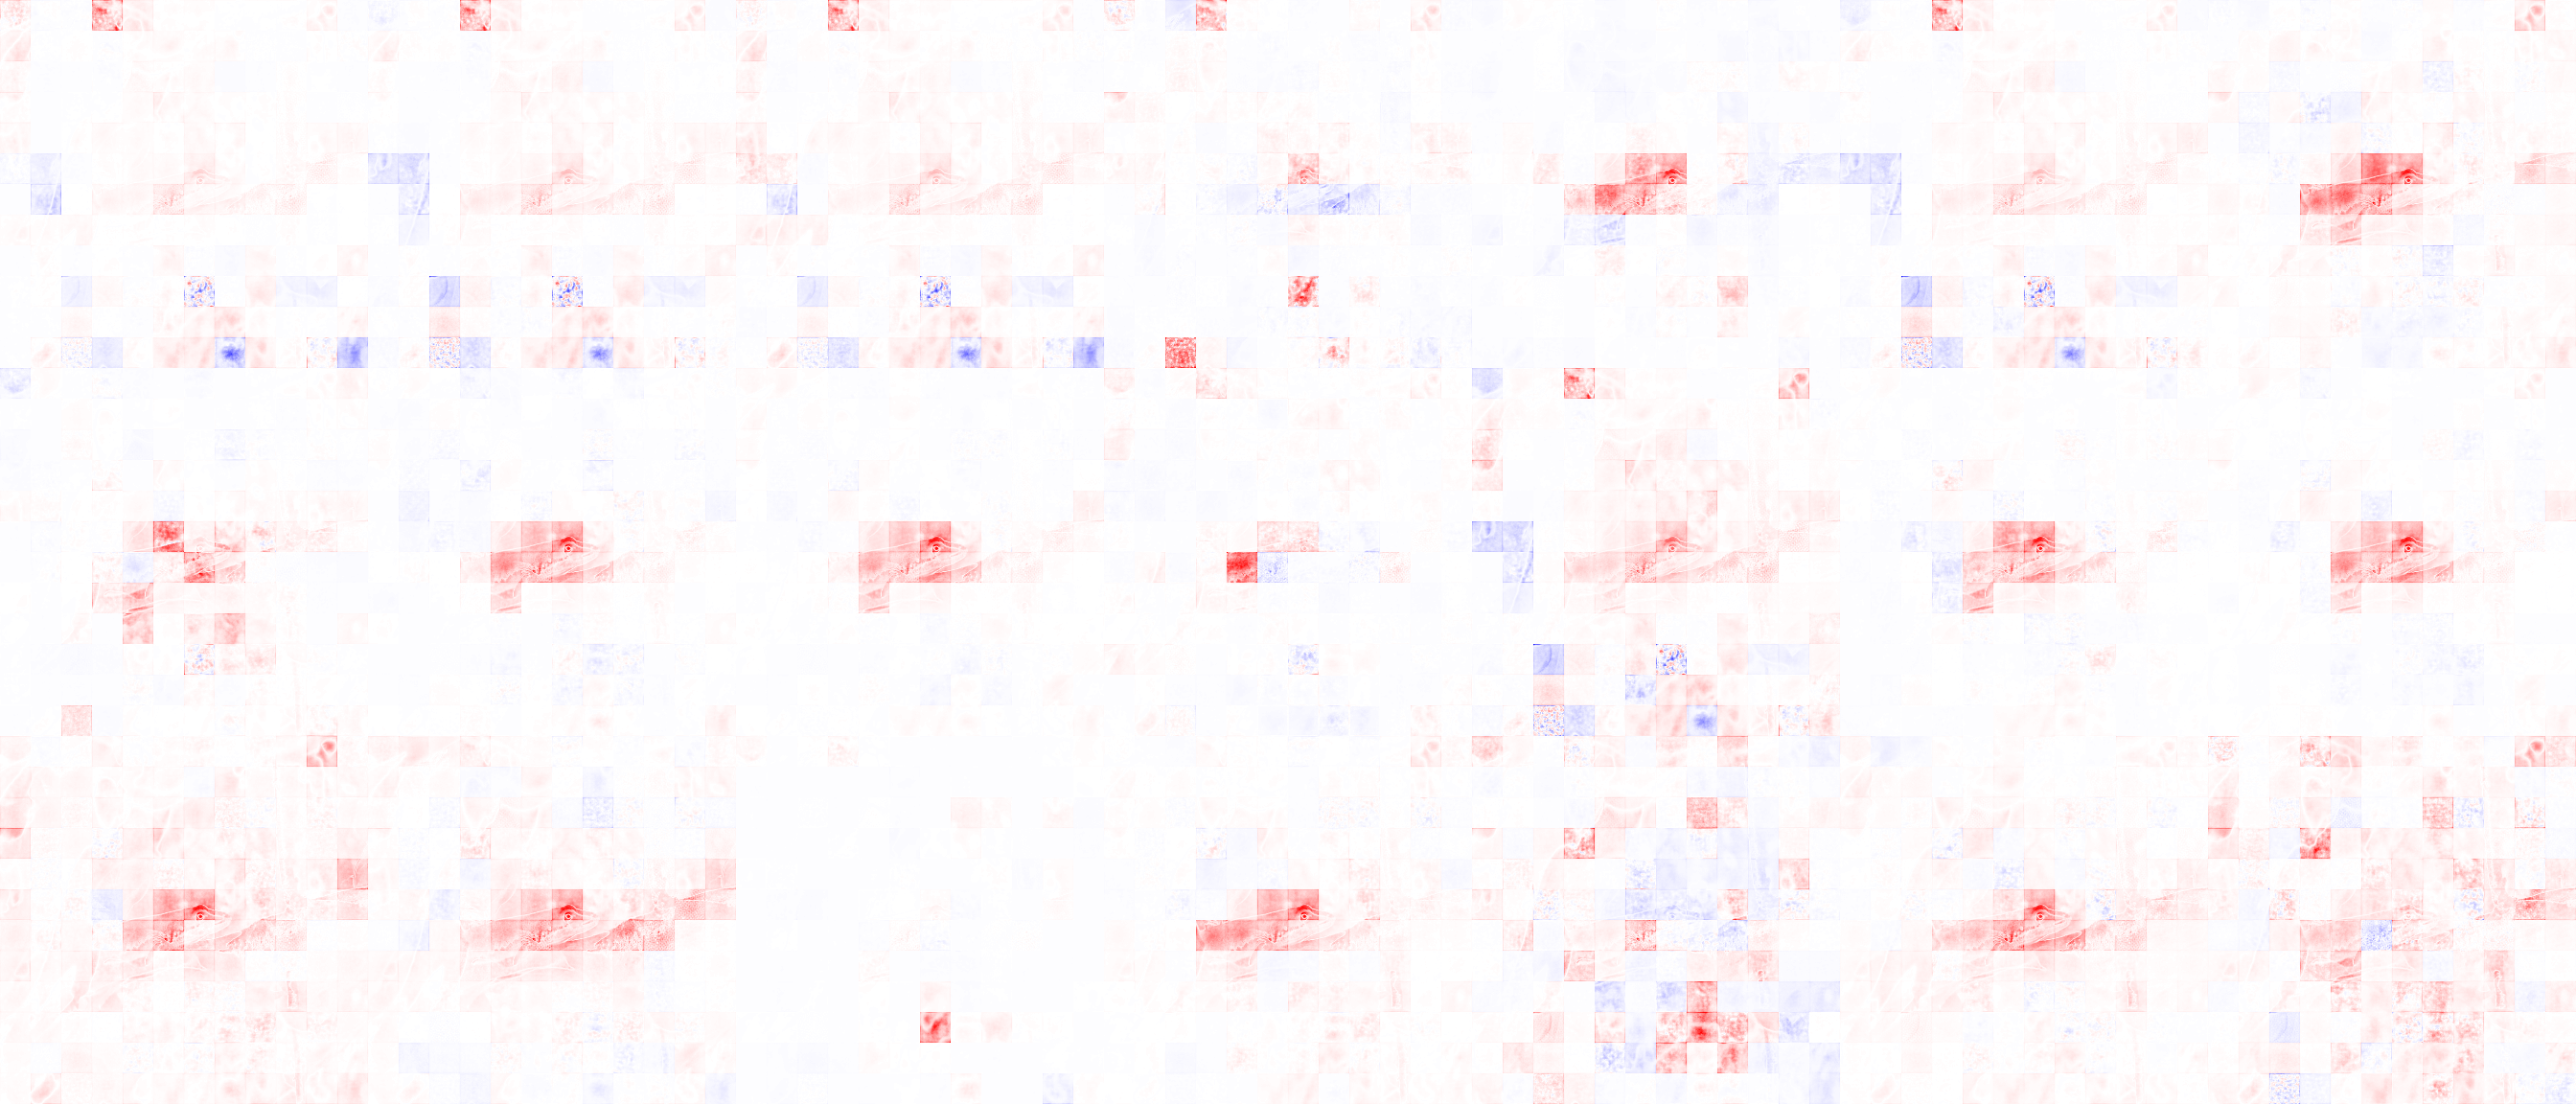

In [ ]:
conditions = [{'y': [46], layer: [id]} for layer, id in top_channel_per_layer.items()]
# Sort the conditions by relevance_per_layer descending
sorted_layers = [layer for _, layer in sorted(zip(relevance_per_layer, layers), reverse=True)]
sorted_conditions = [{'y': [46], layer: [top_channel_per_layer[layer]]} for layer in sorted_layers]

heatmaps, *_ = attribution(sample, sorted_conditions)
print("top channel in each layer")
imgify(heatmaps[0].sum(-3), symmetric=True, grid=(3, len(heatmaps[0])//3))

In [110]:
sorted_conditions

[{'y': [46], 'model.vit.encoder.layer.10.output.dense': [188]},
 {'y': [46], 'model.vit.encoder.layer.11.output.dense': [188]},
 {'y': [46], 'model.vit.encoder.layer.9.output.dense': [188]},
 {'y': [46], 'model.vit.encoder.layer.1.output.dense': [254]},
 {'y': [46], 'model.vit.encoder.layer.7.output.dense': [431]},
 {'y': [46], 'model.vit.encoder.layer.12.output.dense': [188]},
 {'y': [46], 'model.vit.encoder.layer.15.output.dense': [431]},
 {'y': [46], 'model.vit.encoder.layer.4.output.dense': [716]},
 {'y': [46], 'model.vit.encoder.layer.21.output.dense': [482]},
 {'y': [46], 'model.vit.encoder.layer.22.output.dense': [852]},
 {'y': [46], 'model.vit.encoder.layer.2.output.dense': [902]},
 {'y': [46], 'model.vit.encoder.layer.13.output.dense': [188]},
 {'y': [46], 'model.vit.encoder.layer.19.output.dense': [527]},
 {'y': [46], 'model.vit.encoder.layer.20.output.dense': [937]},
 {'y': [46], 'model.vit.encoder.layer.18.output.dense': [695]},
 {'y': [46], 'model.vit.encoder.layer.14.outp

top neuron of top channel in each layer


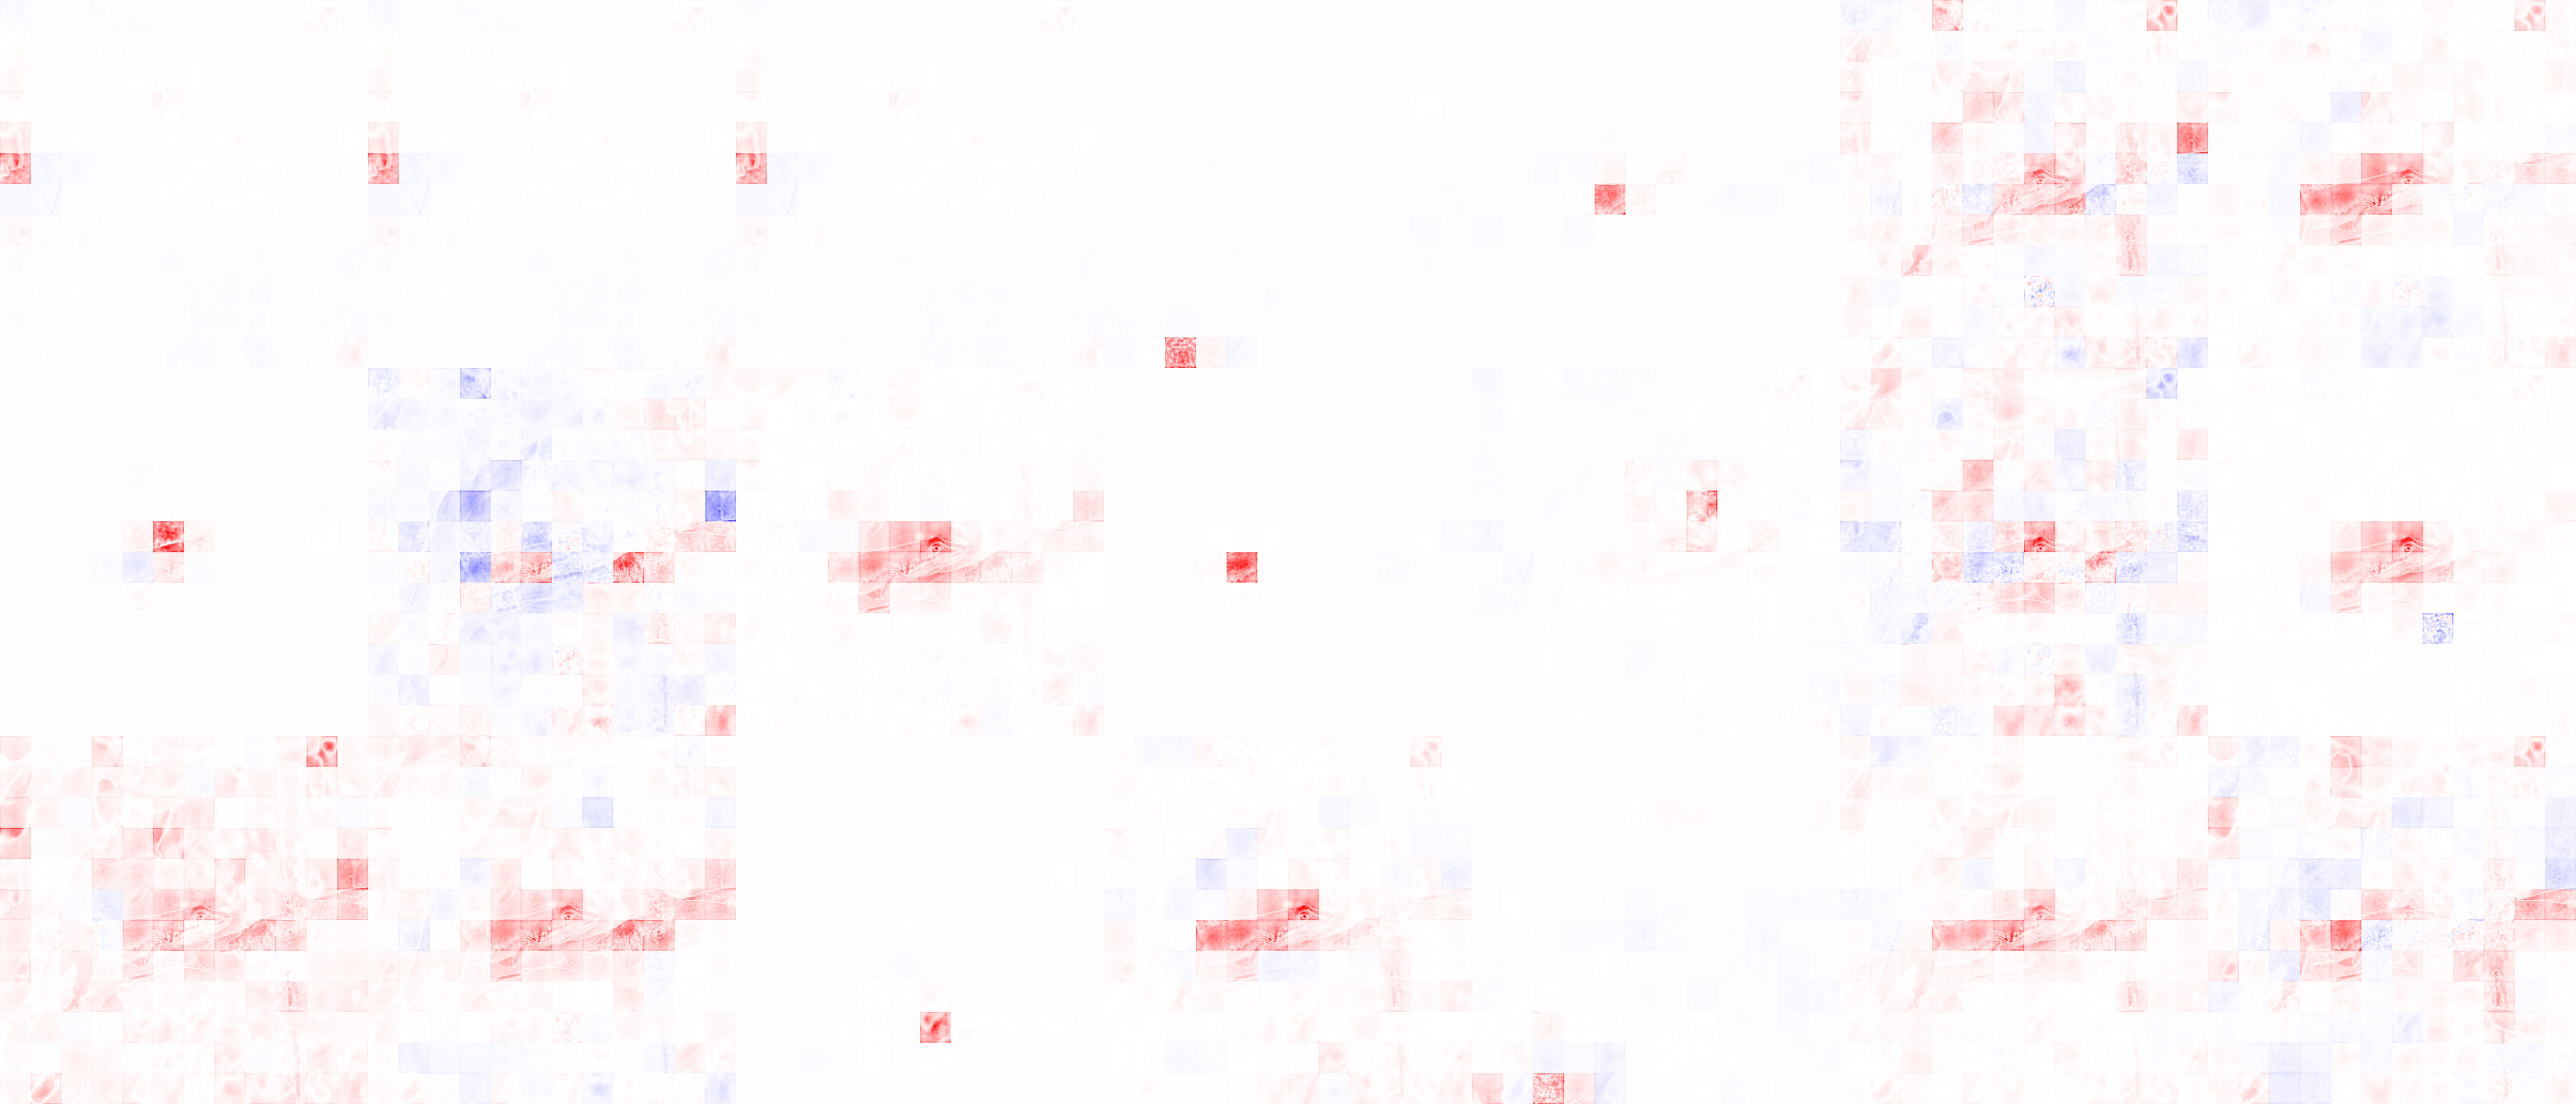

In [109]:
heatmaps, *_ = attribution(sample, sorted_conditions, rf=True)
print("top neuron of top channel in each layer")
imgify(heatmaps[0].sum(-3), symmetric=True, grid=(3, len(heatmaps[0])//3))

### Transformer Neuron Concept

In [23]:
from crp.concepts import TransformerNeuronConcept
tc = TransformerNeuronConcept()

# find top relevant channel (embedding) in layer and relevance to classification in percent
layer_of_interest = 'model.vit.encoder.layer.10.output.dense'
attr = attribution(sample, [{"y": 46}], record_layer=[layer_of_interest])
rel_c = tc.attribute(attr.relevances[layer_of_interest], abs_norm=True)

ImportError: cannot import name 'TransformerNeuronConcept' from 'crp.concepts' (/projects/koegel/code/crp/crp/concepts.py)

In [123]:
# find the six most relevant neurons and their contribution (through top channel) to final classification in percent
rel_values, topk_neuron_ids = torch.topk(rel_c[0], 6)
topk_neuron_ids, rel_values*100

(tensor([188, 310, 721, 670,  25, 584], device='cuda:0'),
 tensor([13.9713,  4.2807,  1.9990,  1.9214,  1.6926,  1.6807], device='cuda:0'))

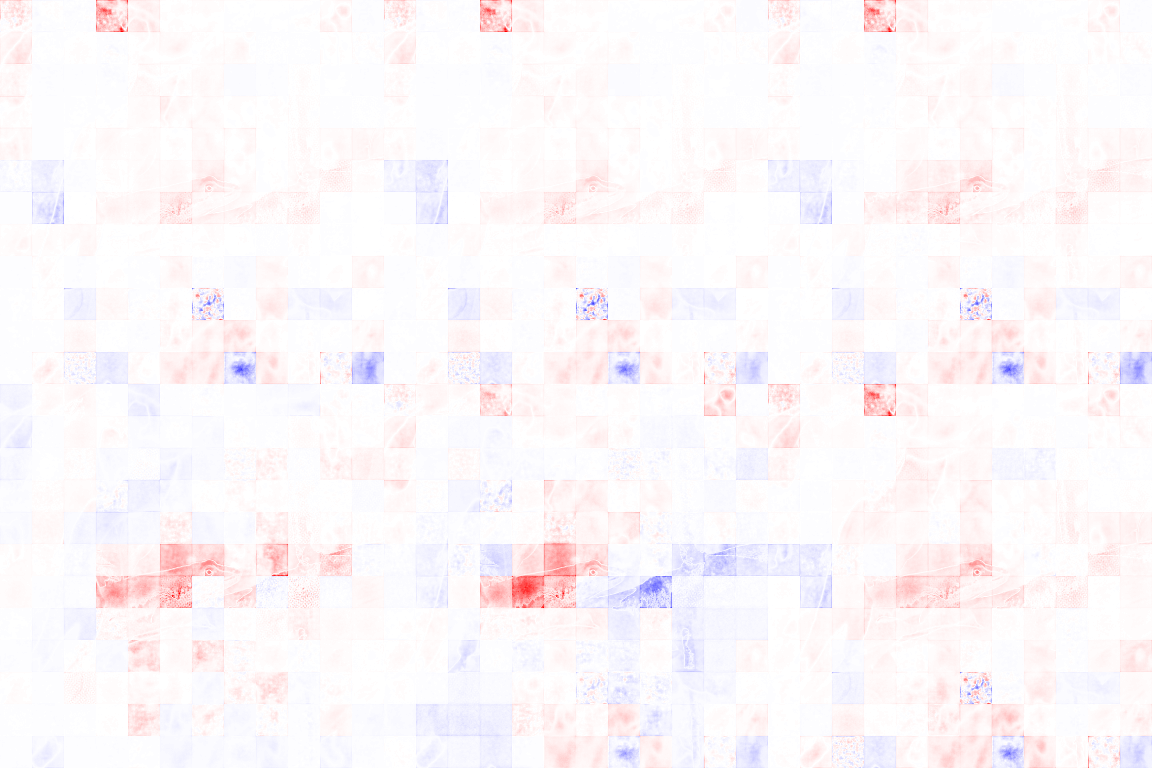

In [124]:
# attribute the most relevant neurons
conditions = [{'y': [46], layer_of_interest: [id]} for id in topk_neuron_ids]
heatmaps, *_ = attribution(sample, conditions, mask_map=tc.mask)
imgify(heatmaps, symmetric=True, grid=(2, len(heatmaps)//2))

### Selective Concepts
Compute attribution for all concepts (neurons) in a layer in parallel and then select the ones which have highest relevance in areas of interest, e.g. the tree branch

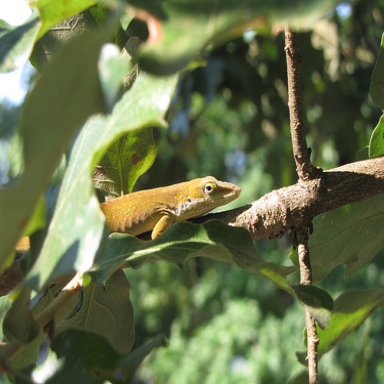

In [24]:
imgify(sample[0])

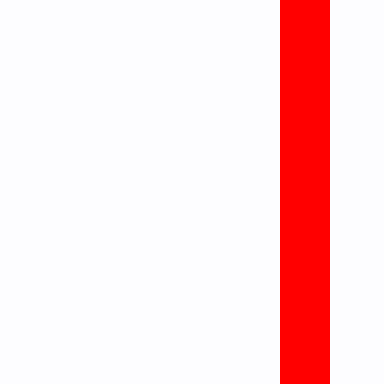

In [25]:
# mask for area of interest (branch)
mask = torch.zeros(384, 384).to(attribution.device)
mask[:, 280:330] = 1

imgify(mask, symmetric=True)

In [44]:
# compute in parallel for all channels of layer
layer_of_interest = 'model.vit.encoder.layer.10.output.dense'
conditions = [{'y': [46], layer_of_interest: [id]} for id in torch.arange(0, 1024)]

rel_c = []
for attr in attribution.generate(sample, conditions, record_layer=[layer_of_interest], batch_size=32, rf=True):
    masked = attr.heatmap[0].sum(-3) * mask[None, :, :]
    rel_c.append(torch.sum(masked, dim=(1, 2)))
rel_c = torch.cat(rel_c)

100%|██████████| 32/32 [01:44<00:00,  3.25s/it]


In [45]:
from crp.helper import abs_norm

indices = torch.topk(rel_c.cpu(), 6).indices
# we norm here, so that we clearly see the contribution inside the masked region as percentage
indices, abs_norm(rel_c)[indices]*100

(tensor([188, 155, 827, 427, 920, 695]),
 tensor([1.0857, 0.9455, 0.8752, 0.7576, 0.7330, 0.7190], device='cuda:0'))

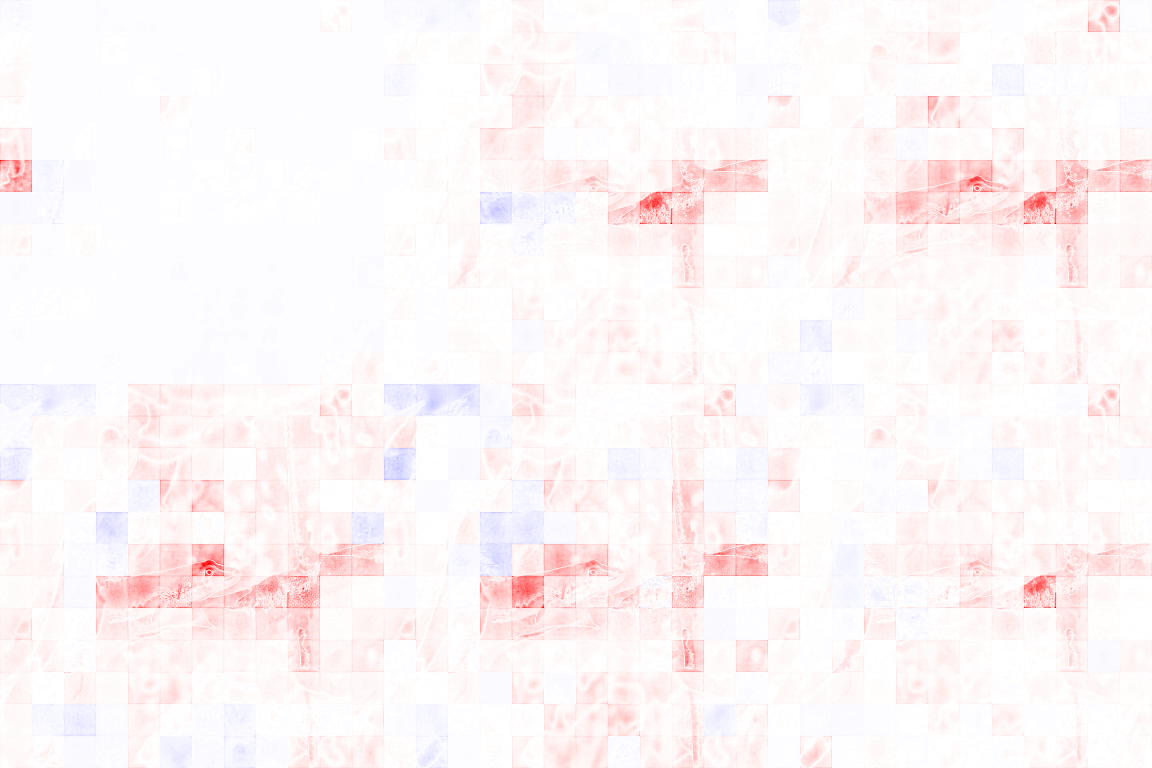

In [46]:
conditions = [{'y': [46], layer_of_interest: [id]} for id in indices]
heatmaps, *_ = attribution(sample, conditions, rf=True)
imgify(heatmaps[0].sum(-3), symmetric=True, grid=(2, len(heatmaps[0])//2))

Now for neurons

In [135]:
# compute in parallel for all neurons of layer
layer_of_interest = 'model.vit.encoder.layer.22.output.dense'
conditions = [{'y': [46], layer_of_interest: [id]} for id in torch.arange(0, 1024)]

rel_n = []
for attr in attribution.generate(sample, conditions, record_layer=[layer_of_interest], mask_map=tc.mask, batch_size=10):
    masked = attr.heatmap * mask[None, :, :]
    rel_n.append(torch.sum(masked, dim=(1, 2)))
rel_n = torch.cat(rel_n)

100%|██████████| 103/103 [01:54<00:00,  1.11s/it]


In [136]:
from crp.helper import abs_norm

indices = torch.topk(rel_n, 6).indices
# we norm here, so that we clearly see the contribution inside the masked region as percentage
indices, abs_norm(rel_n)[indices]*100

(tensor([ 69, 852, 776, 475, 431, 994], device='cuda:0'),
 tensor([0.7635, 0.7392, 0.7242, 0.7153, 0.6598, 0.6291], device='cuda:0'))

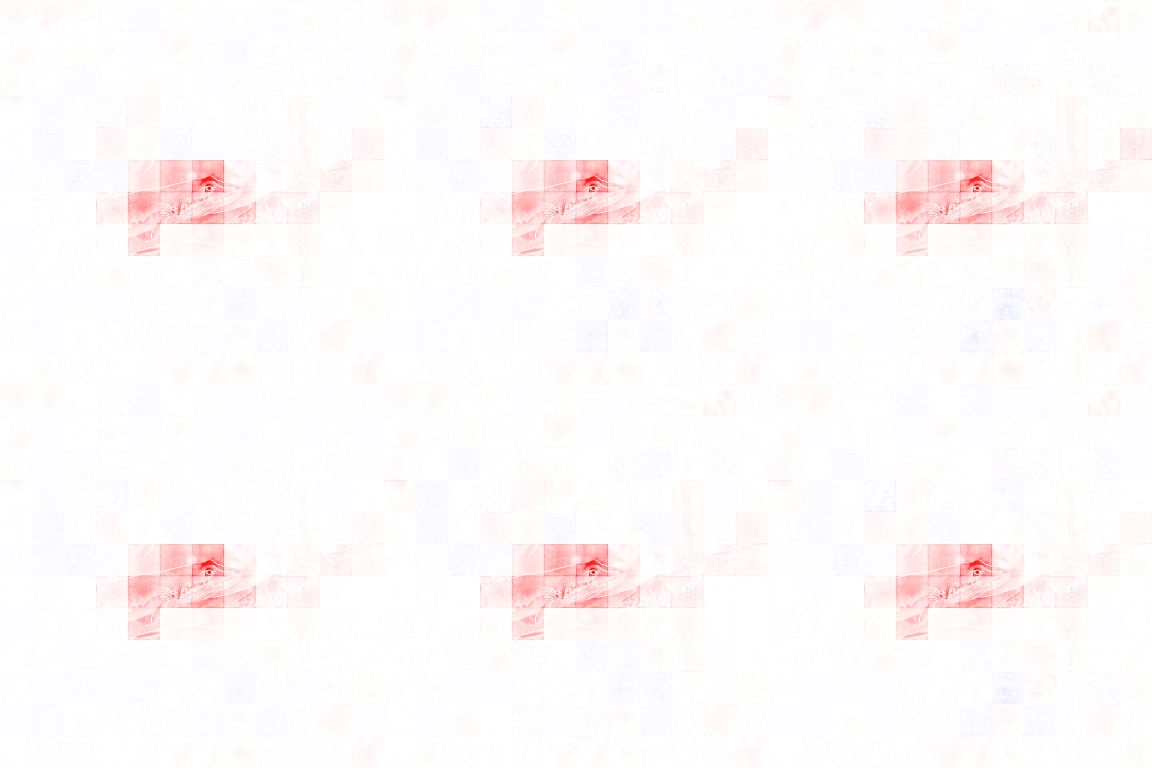

In [137]:
conditions = [{'y': [46], layer_of_interest: [id]} for id in indices]
heatmaps, *_ = attribution(sample, conditions, mask_map=tc.mask)
imgify(heatmaps, symmetric=True, grid=(2, len(heatmaps)//2))

### Decomposition of Concepts

In [170]:
# restrict flow of relevance wrt to lizard class (46) to first neuron in last layer
conditions = [{'y': [46], 'model.vit.encoder.layer.22.output.dense': [32]}]

# record previous layer
attr = attribution(sample, conditions, record_layer=['model.vit.encoder.layer.21.output.dense'])

# compute relevance per channel concept (neuron)
rel_c = cc.attribute(attr.relevances['model.vit.encoder.layer.21.output.dense'], abs_norm=True)

# select the six concepts in layer 21 that contributed the most to the activation of neuron 32 in layer 22
# while being relevant for the classification of the lizard class
indices = torch.topk(rel_c[0], 6).indices
indices

tensor([32, 78, 77, 89, 79, 66], device='cuda:0')

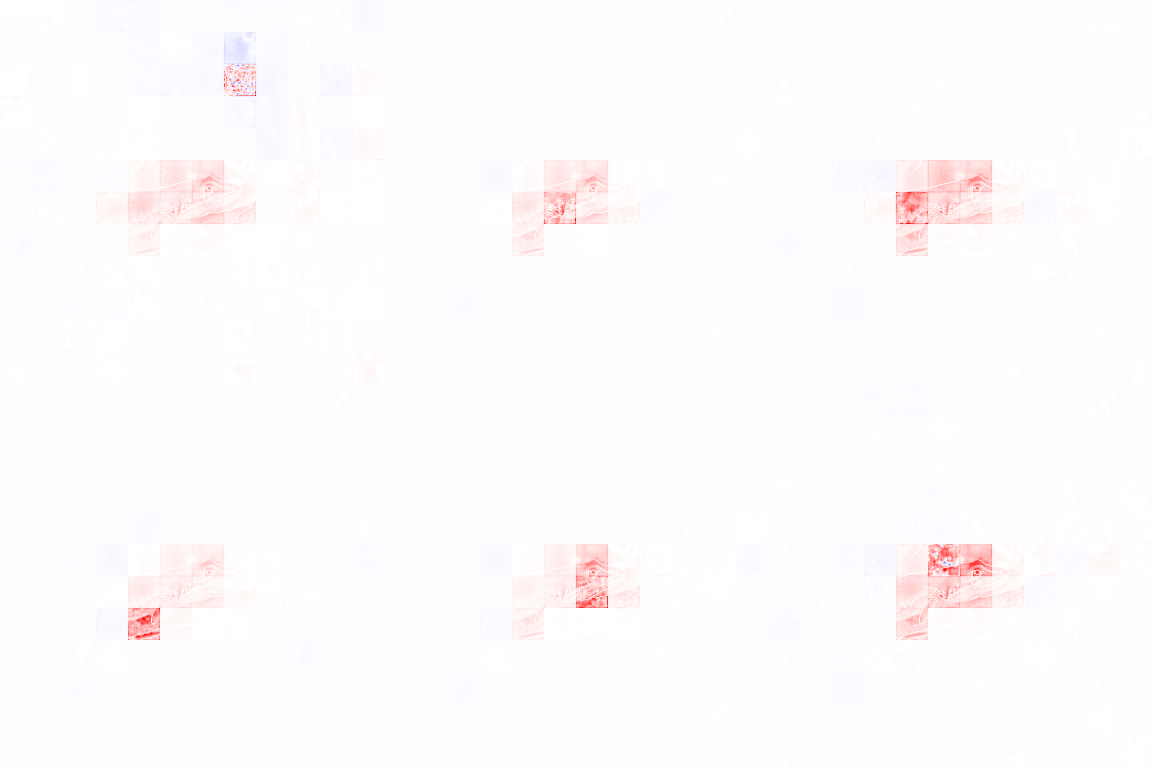

In [172]:
conditions = [{'y': [46], 'model.vit.encoder.layer.22.output.dense': [32], 'model.vit.encoder.layer.21.output.dense': [id]} for id in indices]
heatmaps, *_ = attribution(sample, conditions)
imgify(heatmaps, symmetric=True, grid=(2, len(heatmaps)//2))

# Old Stuff

In [6]:
from torch.fx import passes

g = passes.graph_drawer.FxGraphDrawer(traced, 'modified_vit')
with open("a.svg", "wb") as f:
    f.write(g.get_dot_graph().create_svg())

In [18]:
from torchview import draw_graph
model_graph = draw_graph(modified_vit_model, input_size=x.shape, depth=10, expand_nested=True, roll=True, device='meta', save_graph=True)
model_graph.visual_graph.render(filename='torchview')

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.985266 to fit


'torchview.pdf'

In [16]:
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

zennit_comp = LayerMapComposite([
    (torch.nn.Conv2d, z_rules.Gamma(100)),
    (torch.nn.Linear, z_rules.Gamma(0.05)),
])

# register composite
zennit_comp.register(modified_vit_model)

In [17]:
layer_out = {}
def _generate_hook(layer_name):
    def get_tensor_hook(module, input, output):
        layer_out[layer_name] = output
        try:
            output[0].retain_grad()
        except:
            print(layer_name)
        
    return get_tensor_hook

if 'hooks' in locals():
    for hook in hooks:
        hook.remove()
    
hooks = []
for name, layer in modified_vit_model.vit.encoder.layer.named_modules():
    hooks.append(layer.register_forward_hook(_generate_hook(name)))

In [ ]:
from torchviz import make_dot

In [ ]:
from crp.image import imgify, vis_opaque_img, vis_img_heatmap
from PIL import Image
import requests

url = "https://github.com/rachtibat/LRP-eXplains-Transformers/blob/main/docs/source/_static/cat_dog.jpg?raw=true"
image = Image.open(requests.get(url, stream=True).raw)

input_pixels = processor(images=image, return_tensors="pt")['pixel_values'].to('cuda')

outputs = modified_vit_model(pixel_values=input_pixels.requires_grad_())

# model predicts one of the 1000 ImageNet classes
max_logit, predicted_class_idx = outputs['logits'].max(-1)

make_dot(max_logit, params=dict(modified_vit_model.named_parameters()))

0.intermediate.intermediate_act_fn.module
1.intermediate.intermediate_act_fn.module
2.intermediate.intermediate_act_fn.module
3.intermediate.intermediate_act_fn.module
4.intermediate.intermediate_act_fn.module
5.intermediate.intermediate_act_fn.module
6.intermediate.intermediate_act_fn.module
7.intermediate.intermediate_act_fn.module
8.intermediate.intermediate_act_fn.module
9.intermediate.intermediate_act_fn.module
10.intermediate.intermediate_act_fn.module
11.intermediate.intermediate_act_fn.module
Predicted class (Logit: 12.10): Blenheim spaniel


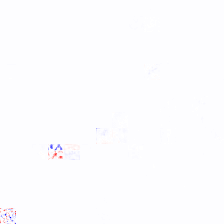

In [18]:
from crp.image import imgify, vis_opaque_img, vis_img_heatmap
from PIL import Image
import requests

url = "https://github.com/rachtibat/LRP-eXplains-Transformers/blob/main/docs/source/_static/cat_dog.jpg?raw=true"
image = Image.open(requests.get(url, stream=True).raw)

input_pixels = processor(images=image, return_tensors="pt")['pixel_values'].to('cuda')

outputs = modified_vit_model(pixel_values=input_pixels.requires_grad_())

# model predicts one of the 1000 ImageNet classes
max_logit, predicted_class_idx = outputs['logits'].max(-1)

# calculate relevance backward pass
max_logit.backward(max_logit)

# normalize the relevance heatmap
relevance = input_pixels.grad[0].sum(0)
relevance = relevance / relevance.abs().max()

# plot the relevance heatmap
print(f"Predicted class (Logit: {max_logit.item():.02f}):", modified_vit_model.config.id2label[predicted_class_idx.item()])
imgify(relevance.cpu(), vmin=-1, vmax=1)

In [19]:
for name, output in layer_out.items():
    if output[0].grad is not None:
        print(name, output[0].grad.sum())
    else:
        print(name)

0.layernorm_before
0.attention.attention.query.module
0.attention.attention.query
0.attention.attention.key.module
0.attention.attention.key
0.attention.attention.value.module
0.attention.attention.value
0.attention.attention.dropout
0.attention.attention tensor(-0.9633, device='cuda:0')
0.attention.output.dense.module
0.attention.output.dense
0.attention.output.dropout
0.attention.output
0.attention tensor(0.1287, device='cuda:0')
0.layernorm_after
0.intermediate.dense.module
0.intermediate.dense
0.intermediate.intermediate_act_fn.module
0.intermediate.intermediate_act_fn
0.intermediate
0.output.dense.module
0.output.dense
0.output.dropout
0.output
0 tensor(9.2552, device='cuda:0')
1.layernorm_before
1.attention.attention.query.module
1.attention.attention.query
1.attention.attention.key.module
1.attention.attention.key
1.attention.attention.value.module
1.attention.attention.value
1.attention.attention.dropout
1.attention.attention tensor(2.6120, device='cuda:0')
1.attention.output.d

/tmp/ipykernel_2407685/193478947.py:2: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  if output[0].grad is not None:


## Traced Model

In [ ]:
import lxt
import lxt.check
import lxt.core
import lxt.functional as lf
import lxt.modules as lm
import importlib
importlib.reload(lxt)
importlib.reload(lxt.check)
importlib.reload(lxt.core)
importlib.reload(lf)
importlib.reload(lm)
#importlib.reload(lxt.models.openclip)

<module 'lxt.modules' from '/scratch/koegel/relevance_dissipation/lxt/lxt/modules.py'>

In [34]:
import importlib
importlib.reload(lf)

<module 'lxt.functional' from '/scratch/koegel/relevance_dissipation/lxt/lxt/functional.py'>

In [25]:
import torch.nn as nn
from zennit.composites import LayerMapComposite
from lxt.core import Composite
import lxt.rules as rules
import lxt.modules as lm
import zennit.rules as z_rules
import lxt.functional as lf
import operator
from transformers.activations import GELUActivation

attnlrp = Composite({
    GELUActivation: rules.IdentityRule,
    nn.LayerNorm: lm.LayerNormEpsilon,
    nn.GELU: rules.IdentityRule,
    nn.Linear: rules.EpsilonRule,
    
    # functions by tracing
    nn.functional.softmax: lf.softmax,
    operator.add: lf.add2,
    operator.mul: lf.mul2,
    operator.truediv: lf.div2,
    operator.matmul: lf.matmul,
    torch.matmul: lf.matmul,
})
# , zennit_composite=LayerMapComposite([
#     (torch.nn.Conv2d, z_rules.Gamma(100)),
#     (torch.nn.Linear, z_rules.Gamma(0.5)),
# ]))

In [30]:
from transformers import ViTImageProcessor, ViTForImageClassification
#checkpoint = "google/vit-large-patch32-384"
checkpoint = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(checkpoint, device_map="cuda")
vit_model = ViTForImageClassification.from_pretrained(checkpoint, attn_implementation="eager", device_map="cuda");

In [31]:
x = torch.randn(1, 3, 224, 224, device="cuda")
#x = torch.randn(1, 3, 384, 384, device="cuda")
traced = attnlrp.register(vit_model, dummy_inputs={'pixel_values': x}, verbose=True)

+----------------------------------------------------------------------------+--------------------------------------+--------------+-------------+
| Parent Module                                                              | Function                             | LRP          | Replaced/   |
| Type                                                                       |                                      | compatible   | Wrapped     |
+============================================================================+======================================+==============+=============+
| vit.embeddings.patch_embeddings.projection                                 | -                                    | ❌           | ❌          |
| torch.nn.modules.conv.Conv2d                                               |                                      |              |             |
+----------------------------------------------------------------------------+--------------------------------------+---

/scratch/koegel/relevance_dissipation/lxt/lxt/core.py:272: UserWarning: LRP incompatible module torch.nn.modules.conv.Conv2d was not replaced!
  warn(f"LRP incompatible module {self._format_type(l_type)} was not replaced!")


In [32]:
traced.graph.print_tabular()

opcode         name                                                   target                                                  args                                                                                                                     kwargs
-------------  -----------------------------------------------------  ------------------------------------------------------  -----------------------------------------------------------------------------------------------------------------------  --------------------------------------------
placeholder    pixel_values                                           pixel_values                                            ()                                                                                                                       {}
get_attr       vit_embeddings_patch_embeddings_projection_weight      vit.embeddings.patch_embeddings.projection.weight       ()                                                                            

## Relevance

In [18]:
from crp.image import imgify, vis_opaque_img, vis_img_heatmap
from PIL import Image
import requests

#url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
#url = 'https://github.com/rachtibat/zennit-crp/blob/master/tutorials/images/lizard.jpg?raw=true'
# url = "https://github.com/rachtibat/LRP-eXplains-Transformers/blob/main/docs/source/_static/cat_dog.jpg?raw=true"
# image = Image.open(requests.get(url, stream=True).raw)
image = Image.open('cat_dog.jpg')

Predicted class (Logit: 12.10): Blenheim spaniel


/scratch/koegel/relevance_dissipation/env/lib/python3.11/site-packages/zennit/image.py:188: RuntimeWarning: invalid value encountered in cast
  array = (array * 255).clip(0, 255).astype(np.uint8)


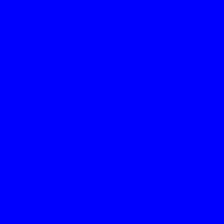

In [33]:
input_pixels = processor(images=image, return_tensors="pt")['pixel_values'].to('cuda')

outputs = traced(pixel_values=input_pixels.requires_grad_())

# model predicts one of the 1000 ImageNet classes
max_logit, predicted_class_idx = outputs['logits'].max(-1)

# calculate relevance backward pass
max_logit.backward(max_logit)

# normalize the relevance heatmap
relevance = input_pixels.grad[0].sum(0)
relevance = relevance / relevance.abs().max()

# plot the relevance heatmap
print(f"Predicted class (Logit: {max_logit.item():.02f}):", vit_model.config.id2label[predicted_class_idx.item()])
imgify(relevance.cpu(), vmin=-1, vmax=1)

In [8]:
# attribute prediction
def attribute_max(image, model=traced):
    inputs = processor(images=image, return_tensors="pt").to('cuda')
    input_pixels = inputs['pixel_values']
    # input_pixels = torch.zeros_like(input_pixels)
    # input_pixels[0,1,112, 112] = 1
    outputs = model(pixel_values=input_pixels.requires_grad_())
    logits = outputs['logits']
    # model predicts one of the 1000 ImageNet classes
    max_logit, predicted_class_idx = logits.max(-1)
    print(f"Predicted class (Logit: {max_logit.item():.02f}):", vit_model.config.id2label[predicted_class_idx.item()])

    max_logit.backward(max_logit)

    # normalize the heatmap
    heatmap = input_pixels.grad[0].sum(0)
    heatmap = heatmap / abs(heatmap).max()
    #heatmaps.append(heatmap.cpu().numpy())

    #imgify(input_pixels[0].detach().cpu(), vmin=-1, vmax=1)
    return imgify(heatmap.cpu(), vmin=-1, vmax=1)

In [11]:
# attribute alternative
def attribute_idx(idx, image, model=traced):
    inputs = processor(images=image, return_tensors="pt").to('cuda')
    input_pixels = inputs['pixel_values']
    outputs = model(pixel_values=input_pixels.requires_grad_())
    logits = outputs['logits']
    # model predicts one of the 1000 ImageNet classes
    logit = logits[0, idx]
    print(f"Alternative class (Logit: {logit.item():.02f}):", vit_model.config.id2label[idx])

    logit.backward(logit)

    # normalize the heatmap
    heatmap = input_pixels.grad[0].sum(0)
    heatmap = heatmap / abs(heatmap).max()
    #heatmaps.append(heatmap.cpu().numpy())

    #imgify(input_pixels[0].detach().cpu(), vmin=-1, vmax=1)
    return imgify(heatmap.cpu(), vmin=-1, vmax=1)

In [13]:
for i in logits.topk(20).indices[0].tolist():
    print(i, vit_model.config.id2label[i])

NameError: name 'logits' is not defined

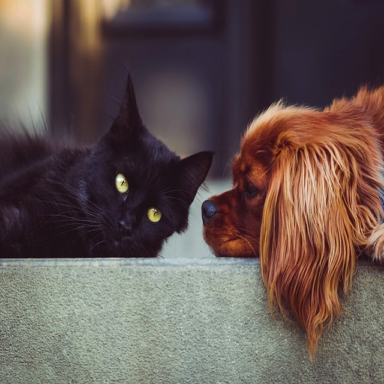

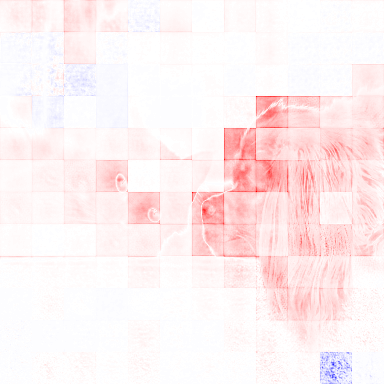

In [733]:
from IPython.display import display
for i in vis_img_heatmap([input_pixels[0]], [heatmap]):
    display(i[0])

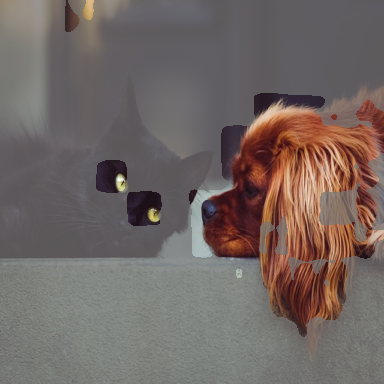

In [734]:
vis_opaque_img([input_pixels[0]], [heatmap], vis_th=0.2)[0]

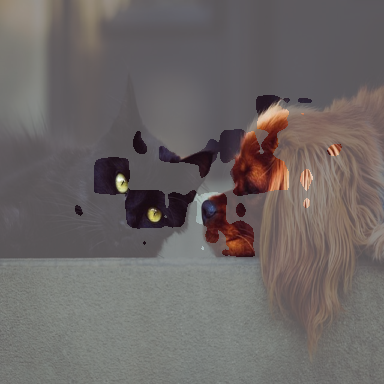

In [735]:
vis_opaque_img([input_pixels[0]], [alt_heatmap], vis_th=0.2)[0]

In [34]:
import itertools
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules
import lxt.functional as lf
# for Vision Transformer, we must perform a grid search for the best gamma hyperparameters
# in general, it is enough to concentrate on the Conv2d and MLP layers
# for simplicity we just use a few values that can be evaluated by hand & looking at the heatmaps

def run_gridsearch(model=traced):
    heatmaps = []
    for conv_gamma, lin_gamma in itertools.product([0.1, 0.5, 100], [0, 0.01, 0.05, 0.1, 1]):

        print("Gamma Conv2d:", conv_gamma, "Gamma Linear:", lin_gamma)

        # we define rules for the Conv2d and Linear layers using 'Zennit'
        zennit_comp = LayerMapComposite([
                (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
                (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
            ])

        # register composite
        zennit_comp.register(model)

        # forward & backward pass
        y = model(input_pixels.requires_grad_())
        logits = y["logits"] #lf.matmul(y[0], y[1].transpose(0, 1))

        # explain the max class
        input_pixels.grad = None
        logits.max().backward()

        # normalize the heatmap
        heatmap = input_pixels.grad[0].sum(0)
        heatmap = heatmap / abs(heatmap).max()
        heatmaps.append(heatmap.cpu().numpy())

        # zennit composites can be removed so that we can register a new one!
        zennit_comp.remove()

    # save the heatmaps as a grid
    from zennit.image import imgify

    return imgify(heatmaps, vmin=-1, vmax=1, grid=(3, 5))#.save('heatmap.png')

In [35]:
run_gridsearch(model=vit_model)

Gamma Conv2d: 0.1 Gamma Linear: 0


ValueError: NaN at <function epsilon_lrp_fn.backward at 0x7f0d642d3c40>